<a href="https://colab.research.google.com/github/teodoraztodorovic/statisticko-programiranje/blob/main/sp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
from scipy.stats import shapiro
import scipy.stats as stats_module
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from scipy.stats import f_oneway
from scipy.stats import kruskal
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
pth = '/content/drive/MyDrive/SP/LengthOfStay.csv'
df = pd.read_csv(pth)
print(df.head())

   eid       vdate rcount gender  dialysisrenalendstage  asthma  irondef  \
0    1   8/29/2012      0      F                      0       0        0   
1    2   5/26/2012     5+      F                      0       0        0   
2    3   9/22/2012      1      F                      0       0        0   
3    4    8/9/2012      0      F                      0       0        0   
4    5  12/20/2012      0      F                      0       0        0   

   pneum  substancedependence  psychologicaldisordermajor  ...     glucose  \
0      0                    0                           0  ...  192.476918   
1      0                    0                           0  ...   94.078507   
2      0                    0                           0  ...  130.530524   
3      0                    0                           0  ...  163.377028   
4      1                    0                           1  ...   94.886654   

   bloodureanitro  creatinine        bmi  pulse  respiration  \
0         

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  object 
 2   rcount                      100000 non-null  object 
 3   gender                      100000 non-null  object 
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother            100000 non-null  int64  
 13  malnutrition   

In [5]:
df.shape

(100000, 28)

In [6]:
df.describe()

,eid,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,...,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,50000.500000,0.036420,0.035270,0.094940,0.039450,0.063060,0.239040,0.051660,0.049390,0.004790,...,10.177455,137.891397,141.963384,14.097185,1.099350,29.805759,73.444720,6.493768,2.123310,4.00103
std,28867.657797,0.187334,0.184462,0.293134,0.194664,0.243072,0.426499,0.221341,0.216682,0.069044,...,5.353131,2.999669,29.992996,12.952454,0.200262,2.003769,11.644555,0.568473,2.050641,2.36031
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.100000,124.912632,-1.005927,1.000000,0.219770,21.992683,21.000000,0.200000,0.000000,1.00000
25%,25000.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,135.871062,121.682383,11.000000,0.964720,28.454235,66.000000,6.500000,1.000000,2.00000
50%,50000.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,9.400000,137.887151,142.088545,12.000000,1.098764,29.807516,73.000000,6.500000,1.000000,4.00000
75%,75000.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,11.500000,139.912885,162.180996,14.000000,1.234867,31.156885,81.000000,6.500000,3.000000,6.00000
max,100000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,245.900000,151.387283,271.444277,682.500000,2.035202,38.935293,130.000000,10.000000,10.000000,17.00000


In [7]:
nans = df.isnull().sum()
nansp = (nans / len(df)) * 100
print(nansp)

eid                           0.0
vdate                         0.0
rcount                        0.0
gender                        0.0
dialysisrenalendstage         0.0
asthma                        0.0
irondef                       0.0
pneum                         0.0
substancedependence           0.0
psychologicaldisordermajor    0.0
depress                       0.0
psychother                    0.0
fibrosisandother              0.0
malnutrition                  0.0
hemo                          0.0
hematocrit                    0.0
neutrophils                   0.0
sodium                        0.0
glucose                       0.0
bloodureanitro                0.0
creatinine                    0.0
bmi                           0.0
pulse                         0.0
respiration                   0.0
secondarydiagnosisnonicd9     0.0
discharged                    0.0
facid                         0.0
lengthofstay                  0.0
dtype: float64


In [8]:
dbl = df.duplicated().sum()
print(dbl)

0


In [9]:
print(df['rcount'].unique())
print(df['rcount'].dtype)

['0' '5+' '1' '3' '4' '2']
object


In [10]:
df['rcount'] = df['rcount'].astype(str).str.strip().str.replace('+', '', regex=False).astype(int)

In [11]:
print(df['rcount'].unique())
print(df['rcount'].dtype)

[0 5 1 3 4 2]
int64


In [12]:
df['vdate'] = pd.to_datetime(df['vdate'])
df['discharged'] = pd.to_datetime(df['discharged'])

print(df[['vdate', 'discharged']].dtypes)
df[['vdate', 'discharged']].head()

vdate         datetime64[ns]
discharged    datetime64[ns]
dtype: object


,vdate,discharged
0,2012-08-29,2012-09-01
1,2012-05-26,2012-06-02
2,2012-09-22,2012-09-25
3,2012-08-09,2012-08-10
4,2012-12-20,2012-12-24


In [13]:
print(df[['vdate', 'discharged']].isnull().sum())

vdate         0
discharged    0
dtype: int64


In [14]:
df['vday'] = df['vdate'].dt.day_name()
df['month'] = df['vdate'].dt.month
df['dday'] = df['discharged'].dt.day_name()

df[['vdate', 'discharged', 'vday', 'dday', 'month']].head(10)

,vdate,discharged,vday,dday,month
0,2012-08-29,2012-09-01,Wednesday,Saturday,8
1,2012-05-26,2012-06-02,Saturday,Saturday,5
2,2012-09-22,2012-09-25,Saturday,Tuesday,9
3,2012-08-09,2012-08-10,Thursday,Friday,8
4,2012-12-20,2012-12-24,Thursday,Monday,12
5,2012-11-27,2012-12-03,Tuesday,Monday,11
6,2012-09-27,2012-10-03,Thursday,Wednesday,9
7,2012-06-04,2012-06-07,Monday,Thursday,6
8,2012-07-05,2012-07-08,Thursday,Sunday,7
9,2012-09-01,2012-09-03,Saturday,Monday,9


In [15]:
df['vday'].value_counts()

,count
vday,
Tuesday,14483
Sunday,14407
Monday,14398
Thursday,14268
Saturday,14239
Wednesday,14214
Friday,13991


In [16]:
df['dday'].value_counts()

,count
dday,
Thursday,14579
Tuesday,14341
Friday,14292
Wednesday,14244
Saturday,14235
Sunday,14233
Monday,14076


In [17]:
df['month'].value_counts()

,count
month,
1,8600
10,8566
5,8482
8,8478
3,8442
12,8392
7,8323
11,8298
9,8242


In [18]:
nc=['hematocrit', 'neutrophils', 'sodium','glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'lengthofstay']
outres = []

for c in nc:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1

    dw = q1 - 1.5 * iqr
    up = q3 + 1.5 * iqr

    outcnt= ((df[c] < dw) | (df[c] > up)).sum()
    outp = (outcnt / len(df)) * 100

    outres.append({'kolona': c, 'donja granica': round(dw, 2), 'gornja granica': round(up, 2), 'broj outliera': outcnt, 'procenat outliera': round(outp, 2) })

outdf = pd.DataFrame(outres)
outdf = outdf.sort_values('procenat outliera', ascending=False)

print(outdf)

           kolona  donja granica  gornja granica  broj outliera  \
8     respiration           6.50            6.50          35167   
4  bloodureanitro           6.50           18.50          19592   
1     neutrophils           2.00           17.20           6515   
0      hematocrit           7.90           15.90           5616   
7           pulse          43.50          103.50           1054   
2          sodium         129.81          145.98            711   
3         glucose          60.93          222.93            695   
5      creatinine           0.56            1.64            675   
6             bmi          24.40           35.21            685   
9    lengthofstay          -4.00           12.00            132   

   procenat outliera  
8              35.17  
4              19.59  
1               6.52  
0               5.62  
7               1.05  
2               0.71  
3               0.70  
5               0.68  
6               0.68  
9               0.13  


In [19]:
df['respiration'].value_counts().head(10)

,count
respiration,
6.5,64833
6.4,1524
6.2,1498
6.6,1473
6.9,1449
6.3,1447
6.7,1431
6.1,1392
6.8,1331


<Axes: >

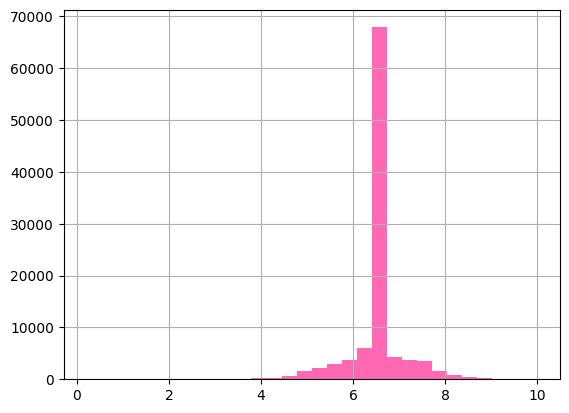

In [20]:
df['respiration'].hist(bins=30, color='hotpink')

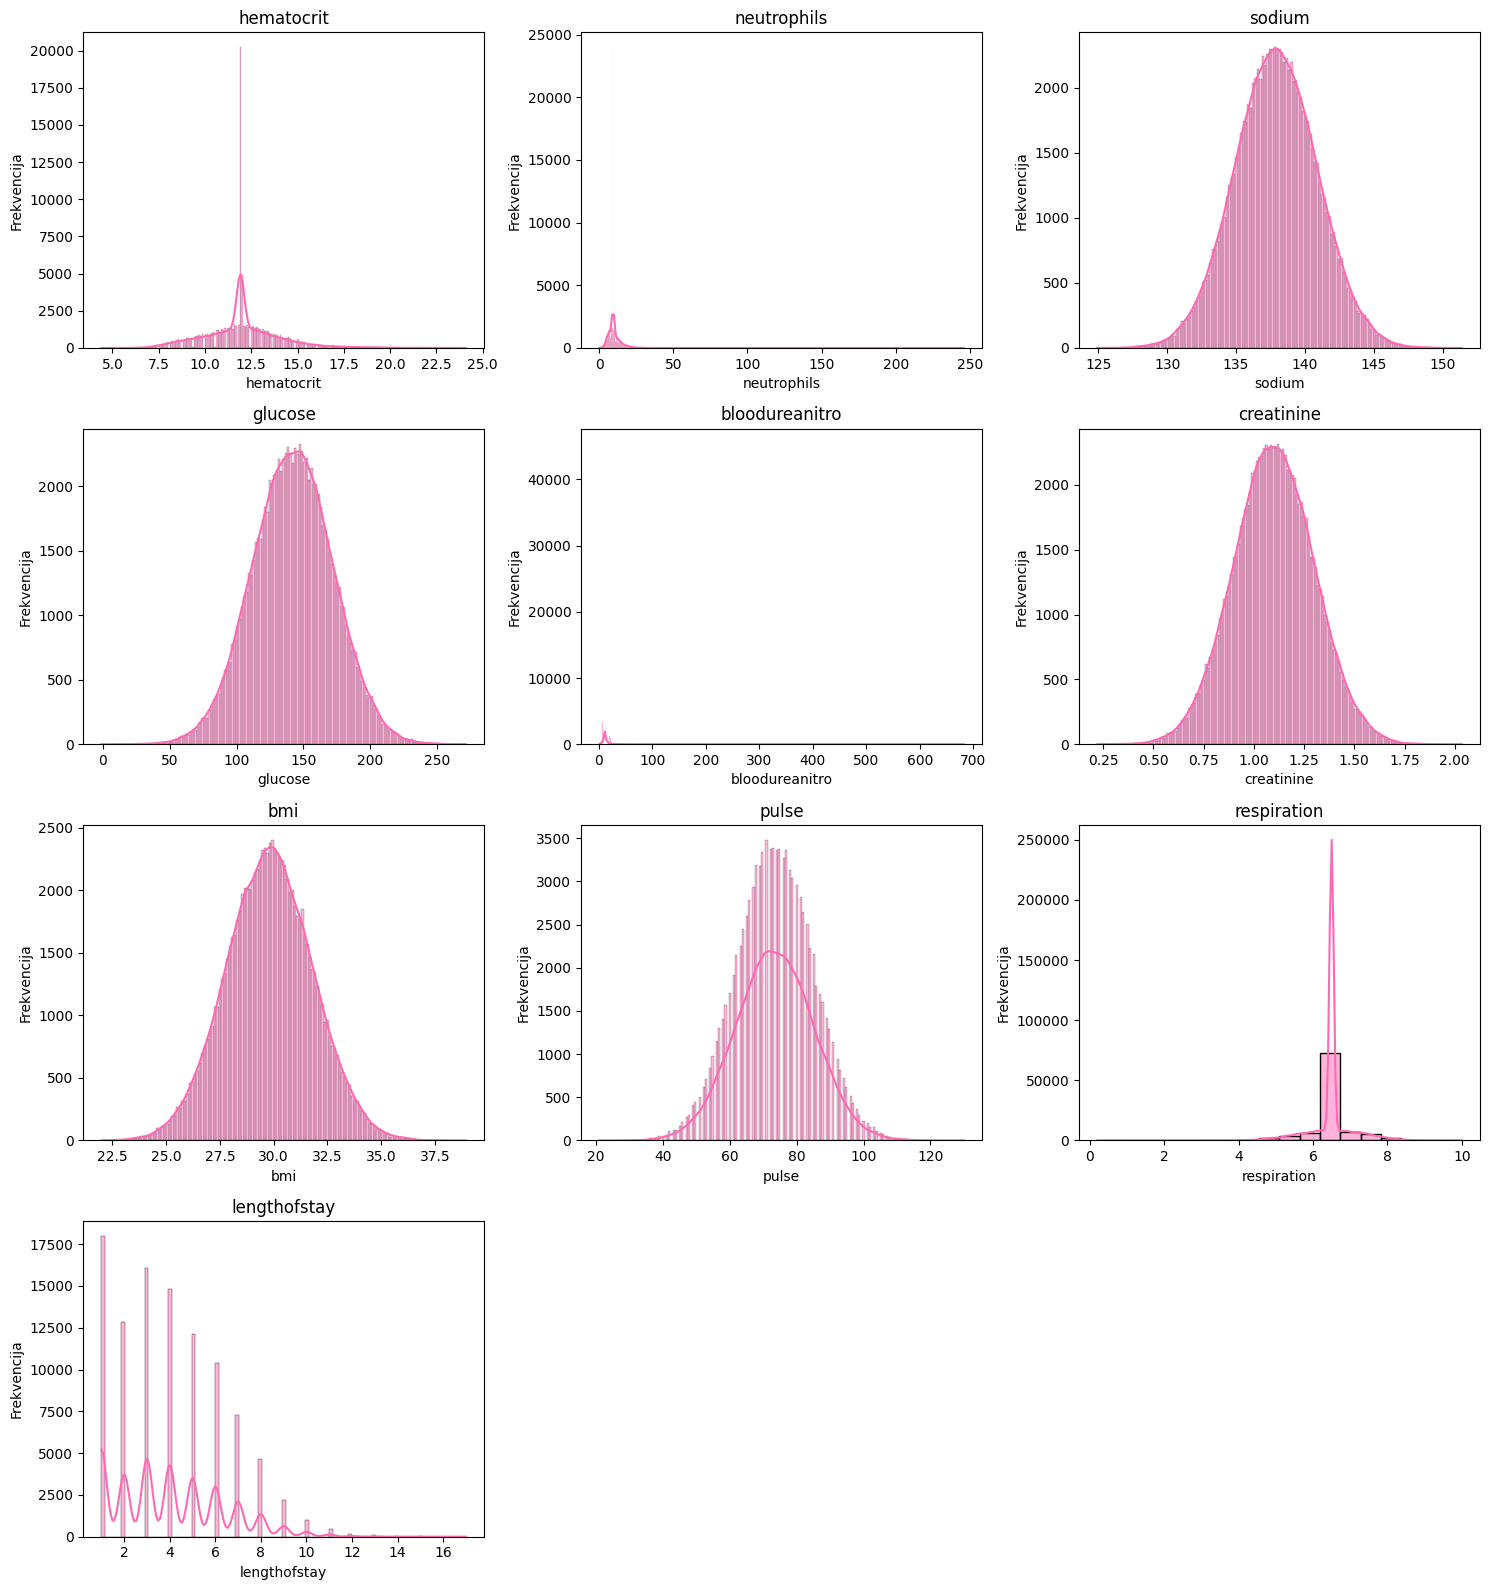

In [21]:
cn = min(3, len(nc))
rn = math.ceil(len(nc) / cn)

plt.figure(figsize=(5 * cn, 4 * rn))

for i, c in enumerate(nc, 1):
    plt.subplot(rn, cn, i)
    sns.histplot(df[c], kde=True, color='hotpink')
    plt.title(f'{c}')
    plt.xlabel(c)
    plt.ylabel('Frekvencija')

plt.tight_layout()
plt.show()

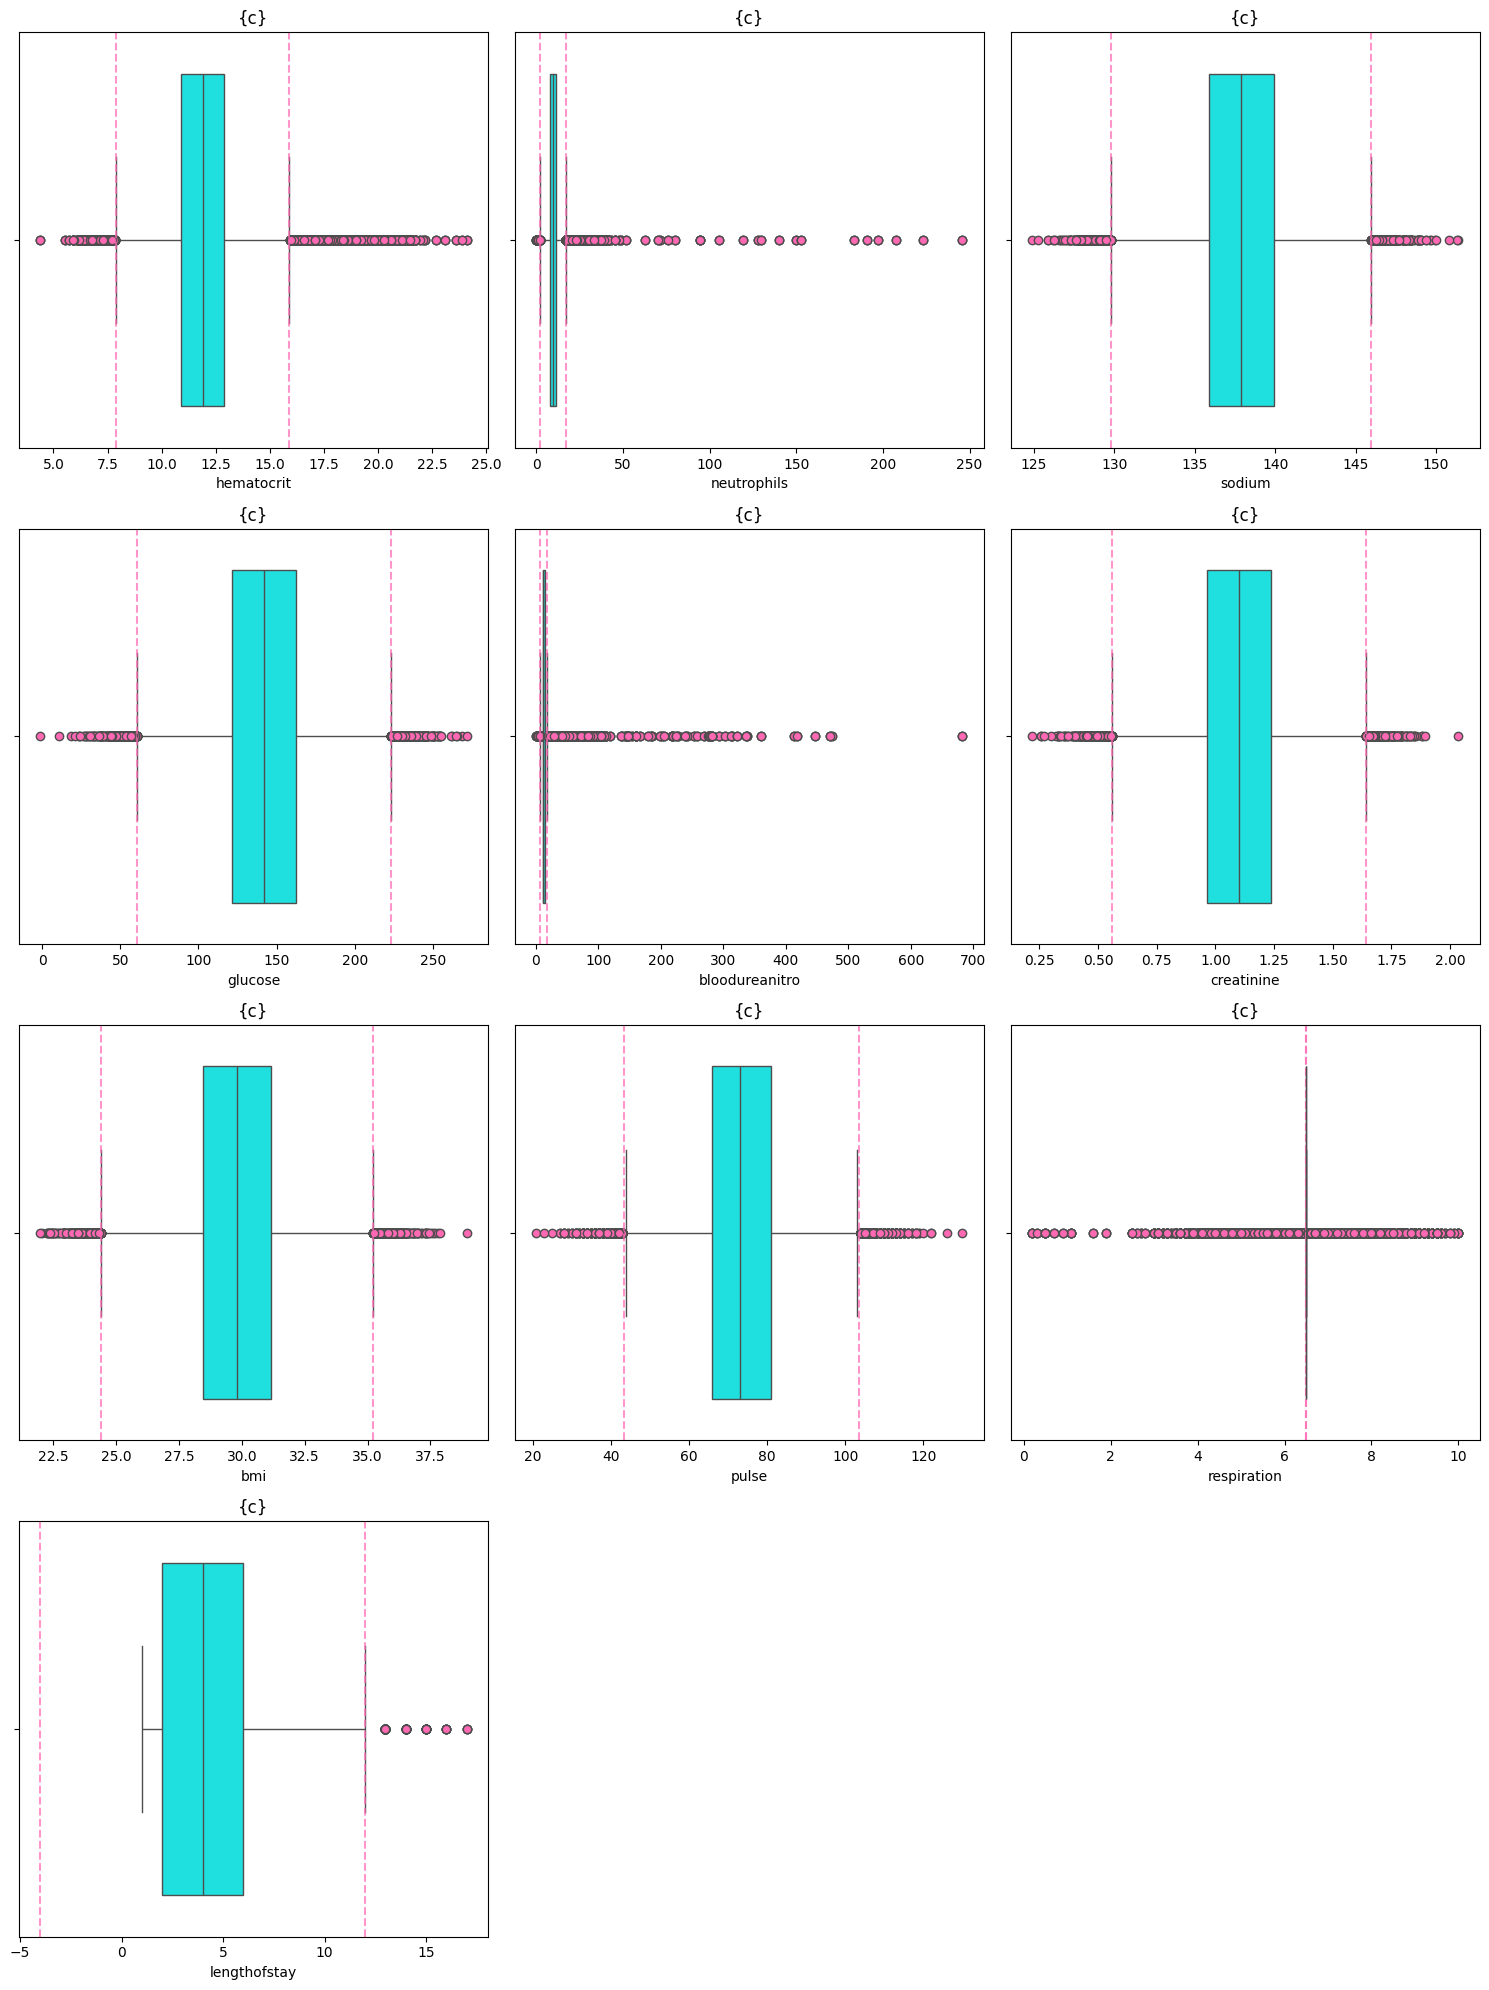

In [22]:
cn = min(3, len(nc))
rn = math.ceil(len(nc) / cn)

plt.figure(figsize=(5 * cn, 5 * rn))

for i, c in enumerate(nc, 1):
    plt.subplot(rn, cn, i)
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    dw = q1 - 1.5 * iqr
    up = q3 + 1.5 * iqr

    sns.boxplot(x=df[c], color='aqua', flierprops={'markerfacecolor':'hotpink', 'marker':'o'})
    plt.axvline(dw, color='hotpink', linestyle='--', alpha=0.7, label='IQR Granice')
    plt.axvline(up, color='hotpink', linestyle='--', alpha=0.7)
    plt.title('{c}')
    plt.xlabel(c)

plt.tight_layout()
plt.show()

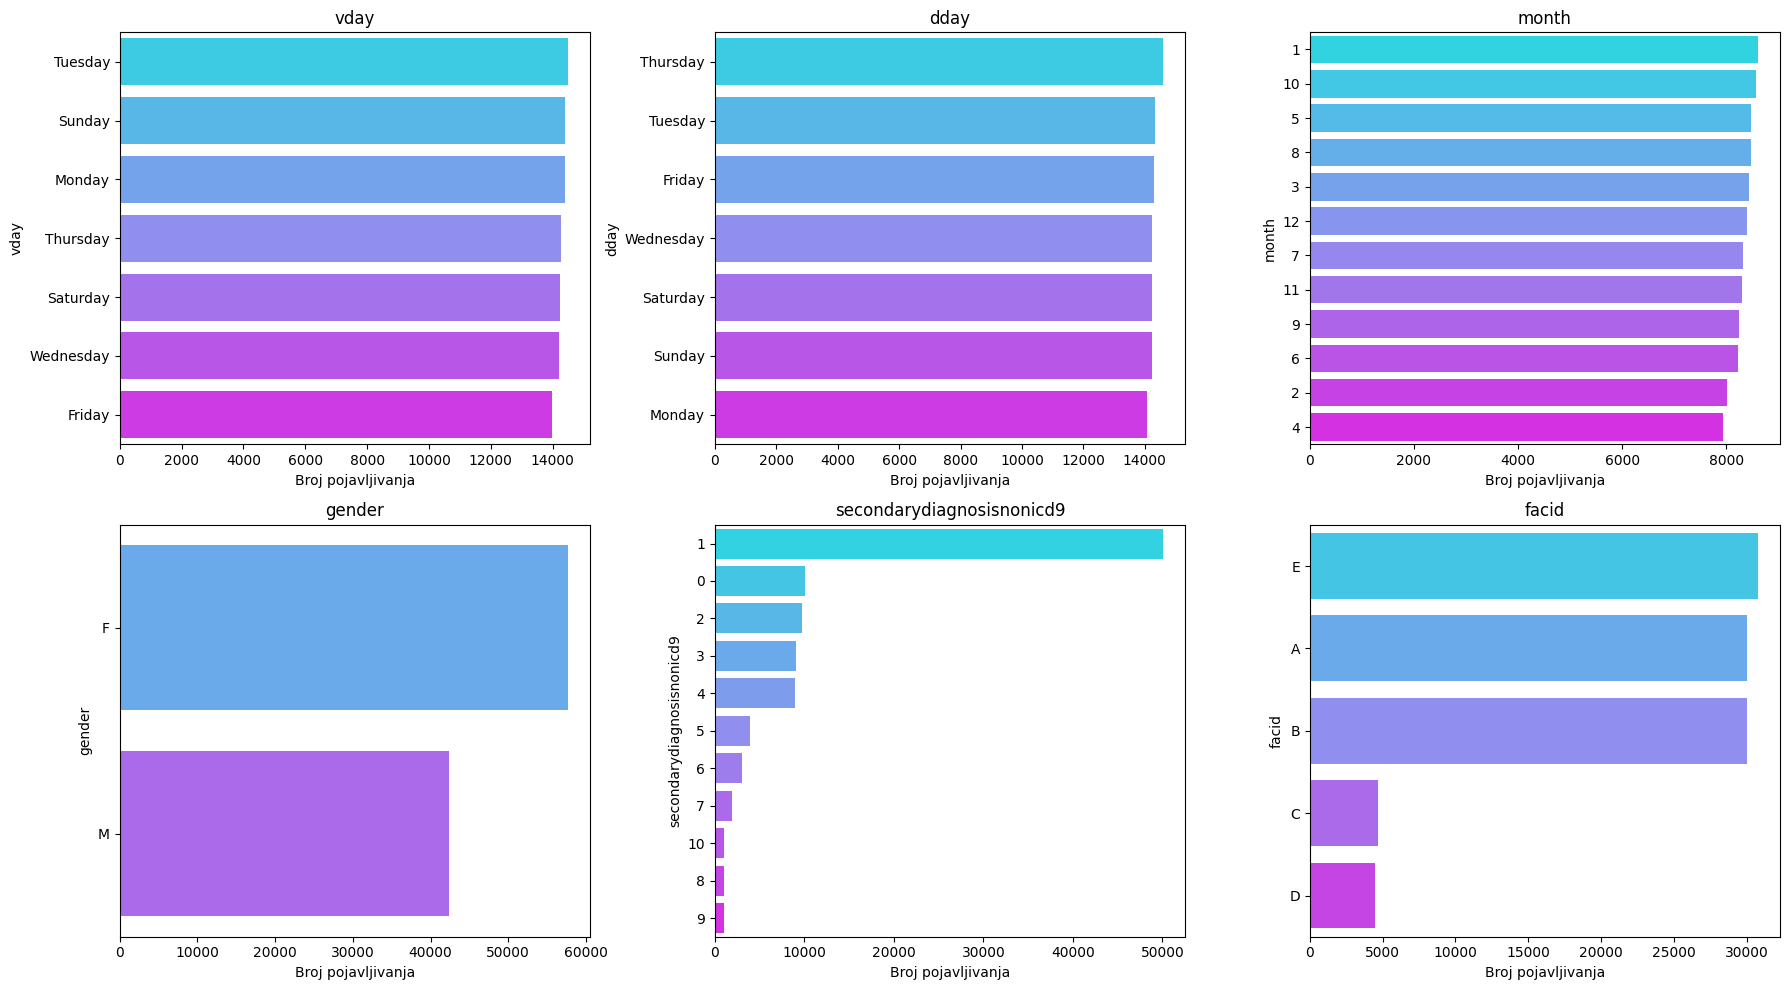

In [23]:
cc = ['vday', 'dday', 'month', 'gender', 'secondarydiagnosisnonicd9', 'facid']

cn = min(3, len(cc))
rn = math.ceil(len(cc) / cn)
plt.figure(figsize=(6 * cn, 5 * rn))

for i, c in enumerate(cc, 1):
    plt.subplot(rn, cn, i)
    ord = df[c].value_counts().head(15).index
    sns.countplot(data=df, y=c, order=ord, palette='cool')
    plt.title(c, fontsize=12)
    plt.ylabel(c)
    plt.xlabel('Broj pojavljivanja')

plt.tight_layout()
plt.show()

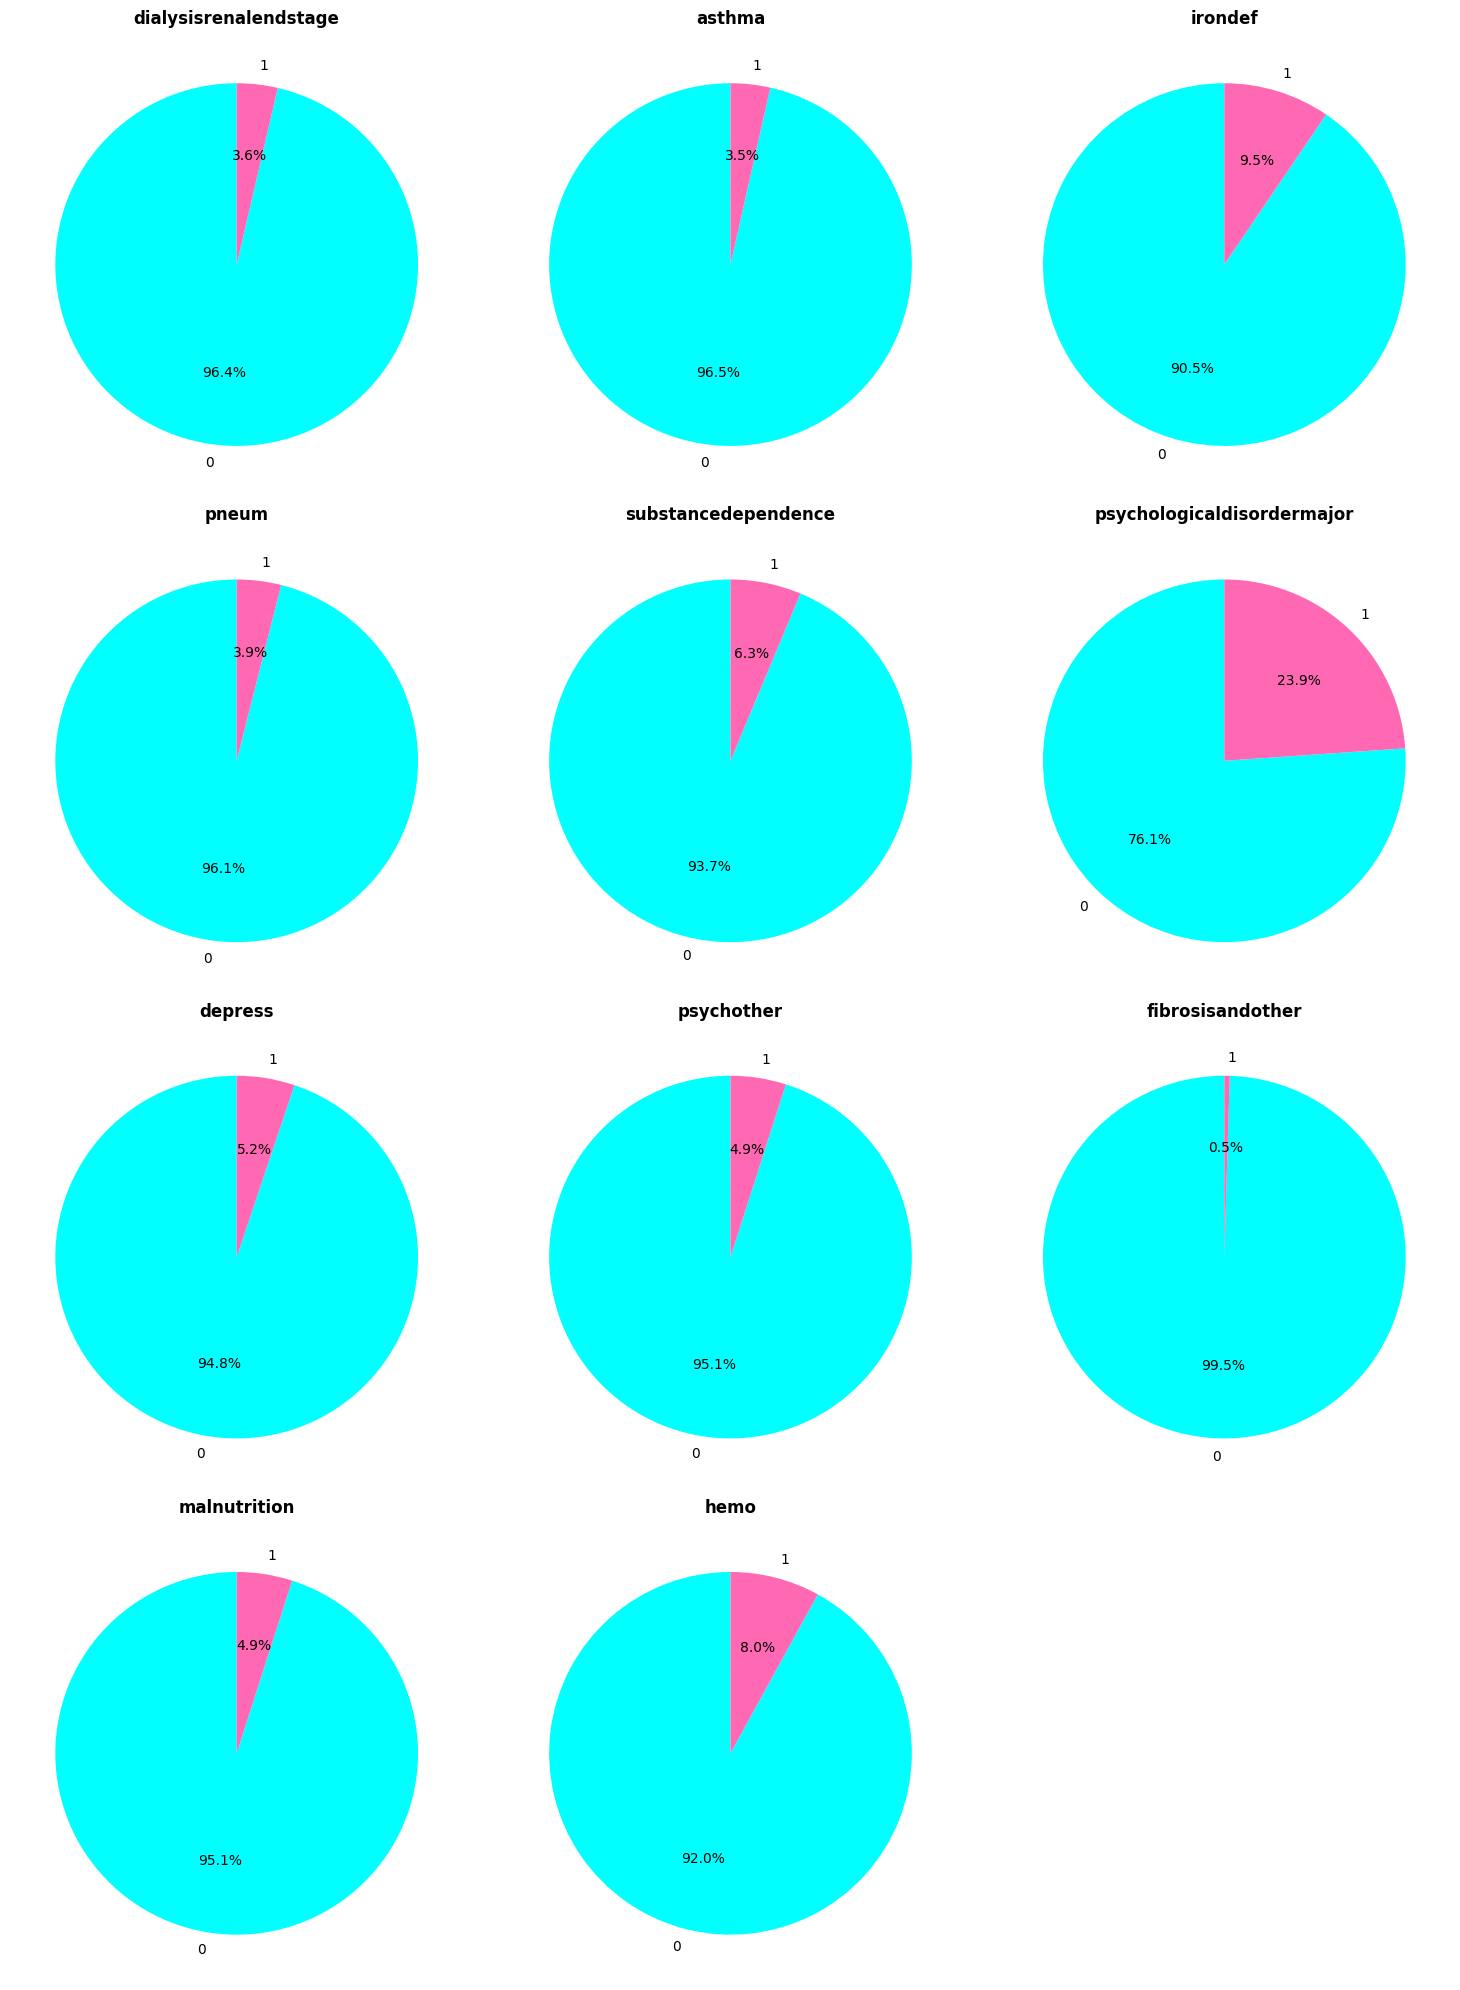

In [24]:
bcc=['dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo' ]
cn= 3
rn = math.ceil(len(bcc) / cn)

plt.figure(figsize=(5 * cn, 5 * rn))

for i, c in enumerate(bcc, 1):
    plt.subplot(rn, cn, i)
    cnt = df[c].value_counts()
    plt.pie(cnt, labels=cnt.index, autopct='%1.1f%%', startangle=90, colors=['aqua', 'hotpink'])
    plt.title(f'{c}', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

In [25]:
st = pd.DataFrame({'srednja vrednost': df[nc].mean(),'medijana': df[nc].median(),'mod': df[nc].mode().iloc[0], 'varijansa': df[nc].var(), 'standardna devijacija': df[nc].std()}).round(3)
print(st)

                srednja vrednost  medijana      mod  varijansa  \
hematocrit                11.976    11.900   11.900      4.128   
neutrophils               10.177     9.400    9.400     28.656   
sodium                   137.891   137.887  133.817      8.998   
glucose                  141.963   142.089  129.720    899.580   
bloodureanitro            14.097    12.000   12.000    167.766   
creatinine                 1.099     1.099    0.897      0.040   
bmi                       29.806    29.808   27.843      4.015   
pulse                     73.445    73.000   71.000    135.596   
respiration                6.494     6.500    6.500      0.323   
lengthofstay               4.001     4.000    1.000      5.571   

                standardna devijacija  
hematocrit                      2.032  
neutrophils                     5.353  
sodium                          3.000  
glucose                        29.993  
bloodureanitro                 12.952  
creatinine                      0

In [26]:
def groupstats(dataframe, gc, t):
    g = dataframe.groupby(gc)[t]
    rezultat = pd.DataFrame({'srednja vrednost': g.mean(), 'medijana': g.median(),'mod': g.apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan), 'standrdna devijacija': g.std(), 'varijansa': g.var(), 'broj opservacija': g.count()}).round(2)
    return rezultat.sort_values('srednja vrednost', ascending=False)

In [27]:
groupstats(df, 'gender', 'lengthofstay')

,srednja vrednost,medijana,mod,standrdna devijacija,varijansa,broj opservacija
gender,,,,,,
M,4.19,4.0,3,2.38,5.66,42357
F,3.86,4.0,1,2.34,5.46,57643


In [28]:
groupstats(df, 'asthma', 'lengthofstay')

,srednja vrednost,medijana,mod,standrdna devijacija,varijansa,broj opservacija
asthma,,,,,,
1,5.01,5.0,3,1.90,3.62,3527
0,3.96,4.0,1,2.37,5.60,96473


In [29]:
groupstats(df, 'facid', 'lengthofstay')

,srednja vrednost,medijana,mod,standrdna devijacija,varijansa,broj opservacija
facid,,,,,,
E,5.16,5.0,3,2.08,4.32,30755
C,4.89,5.0,3,2.09,4.36,4699
D,4.83,4.0,3,2.09,4.35,4499
B,3.28,3.0,1,2.25,5.07,30012
A,3.27,3.0,1,2.25,5.08,30035


In [30]:
groupstats(df, 'rcount', 'lengthofstay')


,srednja vrednost,medijana,mod,standrdna devijacija,varijansa,broj opservacija
rcount,,,,,,
5,8.29,8.0,7,1.34,1.80,4987
4,7.26,7.0,6,1.33,1.78,6941
3,6.27,6.0,5,1.33,1.76,8047
2,5.27,5.0,4,1.31,1.71,9987
1,3.70,4.0,2,1.64,2.70,15007
0,2.72,3.0,1,1.65,2.72,55031


In [31]:
groupstats(df, 'psychologicaldisordermajor', 'lengthofstay')

,srednja vrednost,medijana,mod,standrdna devijacija,varijansa,broj opservacija
psychologicaldisordermajor,,,,,,
1,5.21,5.0,3,2.02,4.06,23904
0,3.62,3.0,1,2.33,5.44,76096


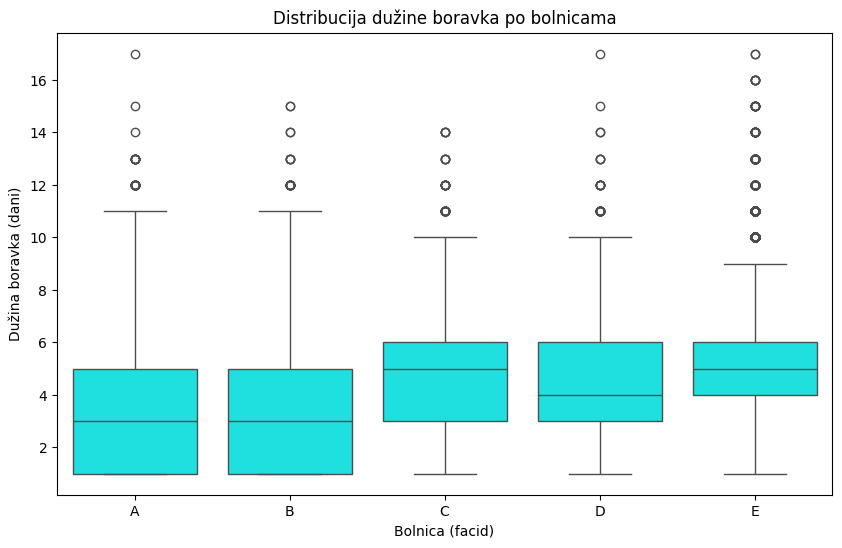

In [32]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='facid', y='lengthofstay', color='aqua' ,order=sorted(df['facid'].unique()))
plt.xlabel('Bolnica (facid)')
plt.ylabel('Dužina boravka (dani)')
plt.title('Distribucija dužine boravka po bolnicama')
plt.show()

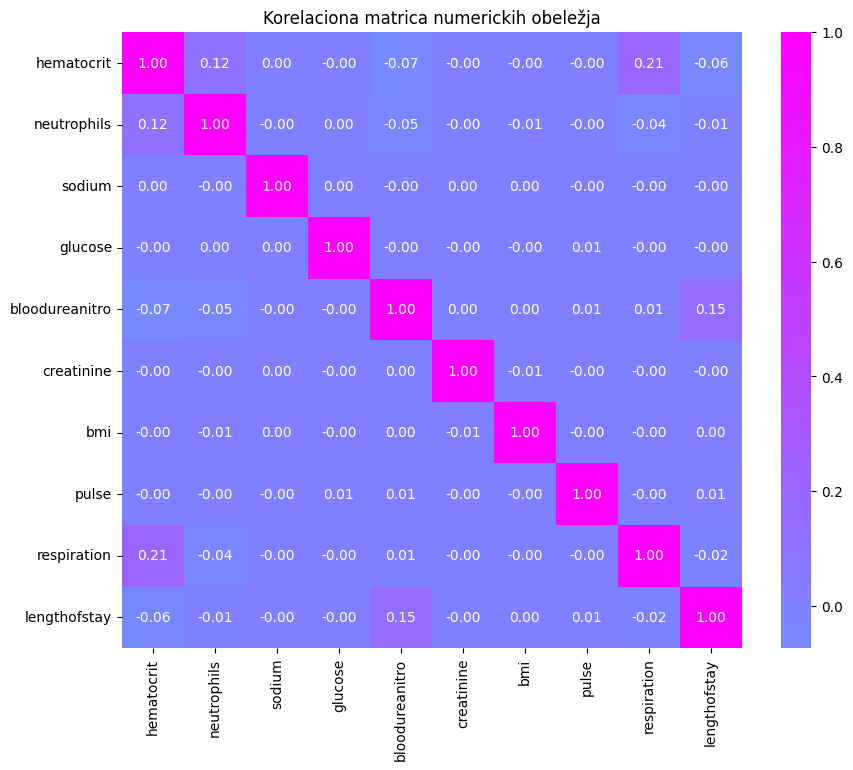

In [33]:
corrm = df[nc].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corrm, annot=True, fmt='.2f', cmap='cool', center=0)
plt.title('Korelaciona matrica numerickih obeležja')
plt.show()

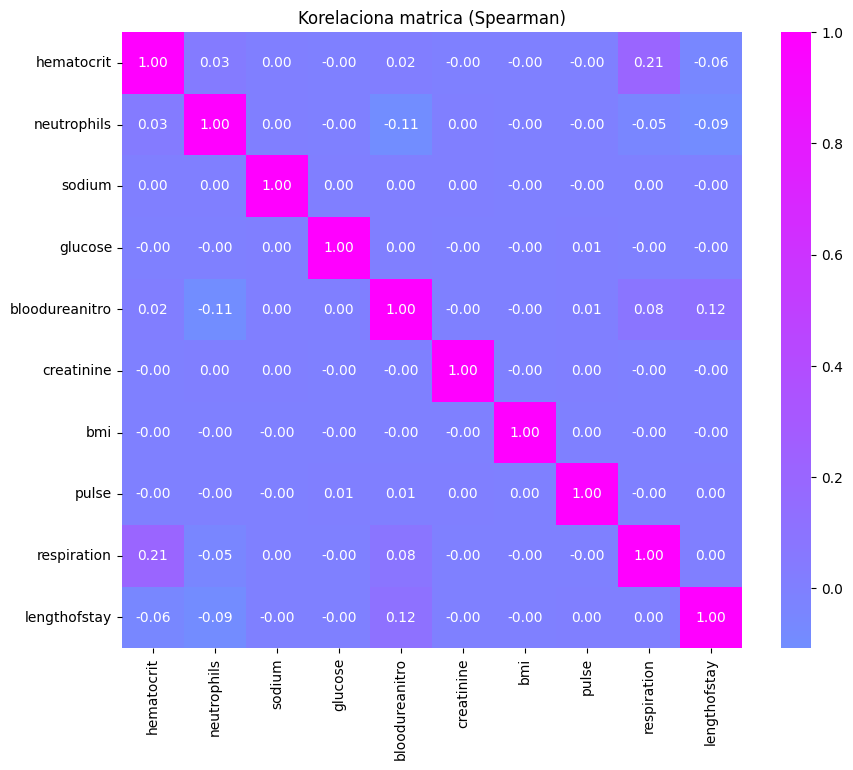

In [34]:
cms = df[nc].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(cms, annot=True, fmt='.2f', cmap='cool', center=0)
plt.title('Korelaciona matrica (Spearman)')
plt.show()

In [35]:
n = len(df)
mean = df['lengthofstay'].mean()
std = df['lengthofstay'].std()
sqrt = std / np.sqrt(n)

print(f"Tačkasta ocena srednje vrednosti: {mean}")
print(f"Standardna greška ocene: {sqrt}")

Tačkasta ocena srednje vrednosti: 4.00103
Standardna greška ocene: 0.007463956490862922


In [36]:
lvl = 0.95
dgr = n - 1

tc = stats.t.ppf((1 + lvl) / 2, dgr)
mrg = tc * sqrt

d = mean - mrg
u = mean + mrg

print(f"95% interval poverenja za srednju vrednost LOSa:")
print(f"[{d:.2f}, {u:.2f}]")

95% interval poverenja za srednju vrednost LOSa:
[3.99, 4.02]


In [37]:
def confint(data, conflevel=0.95):
    n = len(data)
    mean = data.mean()
    se = data.std() / np.sqrt(n)
    tcrit = stats.t.ppf((1 + conflevel) / 2, n - 1)
    margin = tcrit * se

    return {
        'n': n,
        'mean': round(mean, 3),
        'lower': round(mean - margin, 3),
        'upper': round(mean + margin, 3)
    }

In [38]:
resci = []

for hospital in sorted(df['facid'].unique()):
    hdata = df[df['facid'] == hospital]['lengthofstay']
    result = confint(hdata)
    result['facid'] = hospital
    resci.append(result)

cidf = pd.DataFrame(resci)[['facid', 'n', 'mean', 'lower', 'upper']]
print(cidf)

  facid      n   mean  lower  upper
0     A  30035  3.271  3.245  3.296
1     B  30012  3.284  3.258  3.309
2     C   4699  4.890  4.831  4.950
3     D   4499  4.828  4.767  4.889
4     E  30755  5.157  5.134  5.181


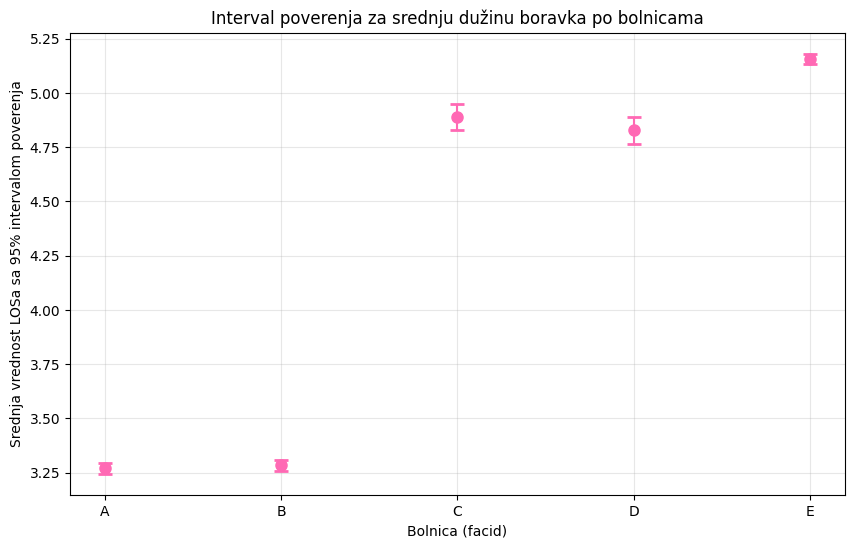

In [39]:
plt.figure(figsize=(10, 6))
plt.errorbar(cidf['facid'], cidf['mean'], yerr=[cidf['mean'] - cidf['lower'], cidf['upper'] - cidf['mean']], fmt='o', capsize=5, capthick=2, markersize=8, color='hotpink')
plt.xlabel('Bolnica (facid)')
plt.ylabel('Srednja vrednost LOSa sa 95% intervalom poverenja')
plt.title('Interval poverenja za srednju dužinu boravka po bolnicama')
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
resci_gender = []

for gender in df['gender'].unique():
    gdata = df[df['gender'] == gender]['lengthofstay']
    result = confint(gdata)
    result['gender'] = gender
    resci_gender.append(result)

cigdf = pd.DataFrame(resci_gender)[['gender', 'n', 'mean', 'lower', 'upper']]
print(cigdf)

  gender      n   mean  lower  upper
0      F  57643  3.860  3.841  3.879
1      M  42357  4.193  4.170  4.215


In [41]:
smp = df['lengthofstay'].sample(5000, random_state=42)
stats, pv = shapiro(smp)

print(f"Shapiro-Wilk statistika: {stats:.5f}")
print(f"p-vrednost: {pv:.10f}")
print("Zaključak:", "Podaci nisu normalno raspoređeni" if pv < 0.05 else "Podaci su normalno raspoređeni")

Shapiro-Wilk statistika: 0.93278
p-vrednost: 0.0000000000
Zaključak: Podaci nisu normalno raspoređeni


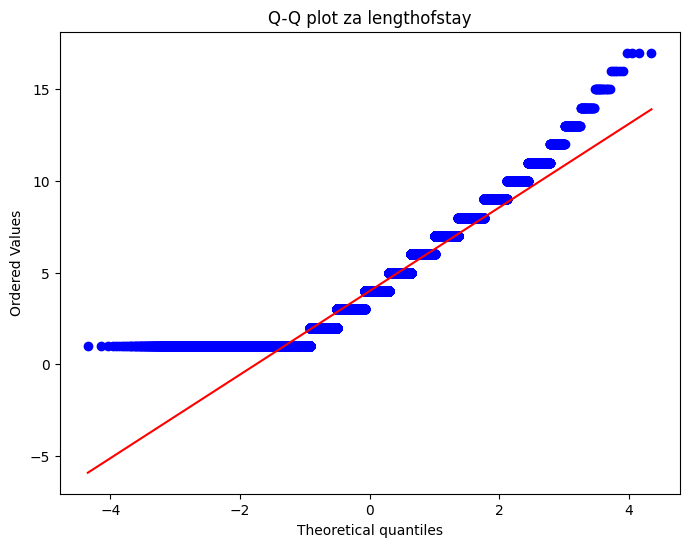

In [42]:
plt.figure(figsize=(8, 6))
stats_module.probplot(df['lengthofstay'], dist="norm", plot=plt)
plt.title('Q-Q plot za lengthofstay')
plt.show()

In [61]:
losf = df[df['gender'] == 'F']['lengthofstay']
losm = df[df['gender'] == 'M']['lengthofstay']

ts, p = ttest_ind(losf, losm, equal_var=False)

print(f"t-statistika: {ts:.4f}")
print(f"p-vrednost: {p:.10f}")
print("Postoji statistički značajna razlika" if p < 0.05 else "Nema statistički značajne razlike")

t-statistika: -21.9923
p-vrednost: 0.0000000000
Postoji statistički značajna razlika


In [44]:
us, pmw = mannwhitneyu(losf, losm, alternative='two-sided')

print(f"Mann-Whitney U statistika: {us}")
print(f"p-vrednost: {pmw:.10f}")

Mann-Whitney U statistika: 1120574068.0
p-vrednost: 0.0000000000


In [45]:
gh = [df[df['facid'] == b]['lengthofstay'] for b in sorted(df['facid'].unique())]

fs, panova = f_oneway(*gh)

print(f"F-statistika: {fs}")
print(f"p-vrednost: {panova:.40f}")
print("Bar jedna bolnica se značajno razlikuje" if panova < 0.05 else "Nema značajne razlike među bolnicama")

F-statistika: 4153.335919023173
p-vrednost: 0.0000000000000000000000000000000000000000
Bar jedna bolnica se značajno razlikuje


In [46]:
hs, pkw = kruskal(*gh)

print(f"H-statistika: {hs:.3f}")
print(f"p-vrednost: {pkw:.10f}")

H-statistika: 16123.461
p-vrednost: 0.0000000000


In [47]:
catt = pd.crosstab(df['gender'], df['psychologicaldisordermajor'])
print(catt)

chi2s, pchi2, dof, expected = chi2_contingency(catt)

print(f"\nChi2 statistika: {chi2s:.3f}")
print(f"p-vrednost: {pchi2:.10f}")
print(f"Stepeni slobode: {dof}")

psychologicaldisordermajor      0      1
gender                                  
F                           46979  10664
M                           29117  13240

Chi2 statistika: 2184.076
p-vrednost: 0.0000000000
Stepeni slobode: 1


In [48]:
pred = ['hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'rcount']
corrlos = pd.DataFrame({'pearson': df[pred + ['lengthofstay']].corr()['lengthofstay'].drop('lengthofstay'),'spearman': df[pred + ['lengthofstay']].corr(method='spearman')['lengthofstay'].drop('lengthofstay')}).round(3)
corrlos.sort_values('spearman', key=abs, ascending=False)

,pearson,spearman
rcount,0.750,0.707
bloodureanitro,0.148,0.117
neutrophils,-0.011,-0.091
hematocrit,-0.064,-0.058
pulse,0.007,0.004
sodium,-0.004,-0.003
creatinine,-0.004,-0.003
respiration,-0.022,0.001
glucose,-0.003,-0.000
bmi,0.000,-0.000


In [49]:
Xc = 'rcount'

X = df[Xc]
y = df['lengthofstay']
X = sm.add_constant(X)

modelOLS = sm.OLS(y, X).fit()
print(modelOLS.summary())

                            OLS Regression Results                            
Dep. Variable:           lengthofstay   R-squared:                       0.562
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                 1.282e+05
Date:                Mon, 13 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:58:47   Log-Likelihood:            -1.8652e+05
No. Observations:              100000   AIC:                         3.730e+05
Df Residuals:                   99998   BIC:                         3.731e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7189      0.006    445.566      0.0

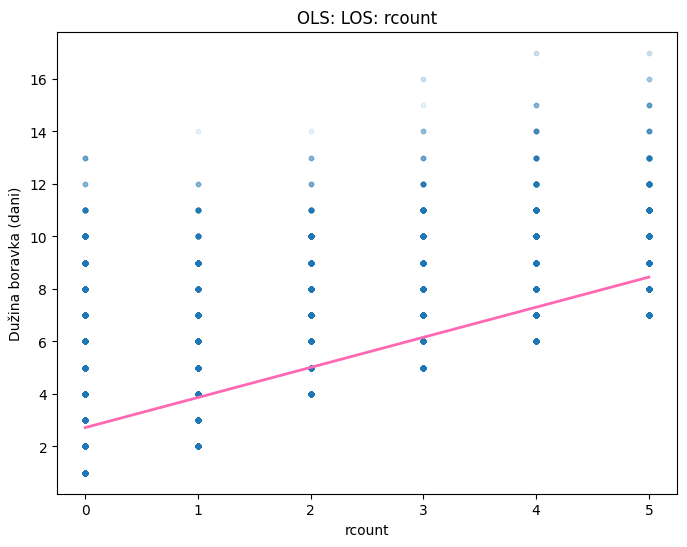

In [50]:
plt.figure(figsize=(8, 6))
plt.scatter(df[Xc], df['lengthofstay'], alpha=0.1, s=10)
plt.plot(df[Xc].sort_values(),modelOLS.predict(sm.add_constant(df[Xc].sort_values())), color='hotpink', linewidth=2)
plt.xlabel(Xc)
plt.ylabel('Dužina boravka (dani)')
plt.title(f'OLS: LOS: {Xc}')
plt.show()

In [51]:
predm = ['rcount', 'hematocrit', 'neutrophils', 'sodium', 'glucose','bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'dialysisrenalendstage', 'asthma', 'psychologicaldisordermajor']
Xm = df[predm]
y = df['lengthofstay']
Xm = sm.add_constant(Xm)

modelm = sm.OLS(y, Xm).fit()
print(modelm.summary())

                            OLS Regression Results                            
Dep. Variable:           lengthofstay   R-squared:                       0.687
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                 1.687e+04
Date:                Mon, 13 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:58:48   Log-Likelihood:            -1.6971e+05
No. Observations:              100000   AIC:                         3.395e+05
Df Residuals:                   99986   BIC:                         3.396e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [52]:
X_vif = sm.add_constant(df[predm])

vif_df = pd.DataFrame()
vif_df['pred'] = X_vif.columns
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i)
                  for i in range(X_vif.shape[1])]

vif_df = vif_df[vif_df['pred'] != 'const']
vif_df.sort_values('VIF', ascending=False)

,pred,VIF
11,dialysisrenalendstage,1.099670
6,bloodureanitro,1.086559
2,hematocrit,1.083981
10,respiration,1.053728
3,neutrophils,1.038058
13,psychologicaldisordermajor,1.032701
12,asthma,1.002805
9,pulse,1.000210
1,rcount,1.000130
5,glucose,1.000123


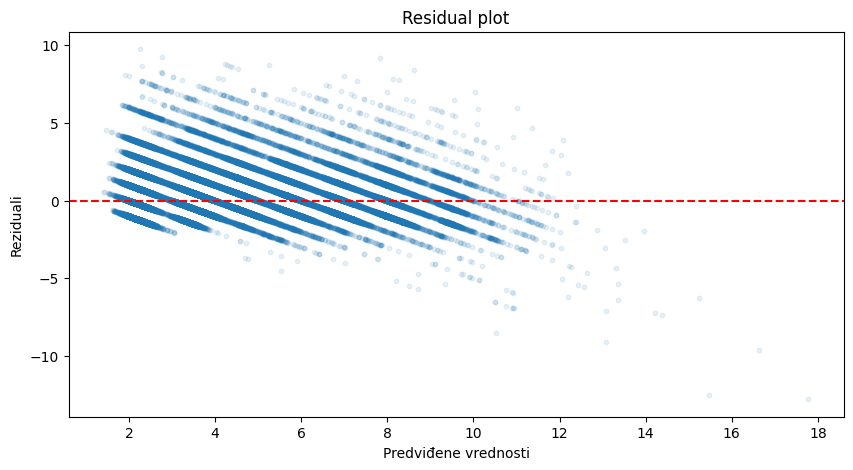

In [53]:
predict = modelm.predict(Xm)
residual = y - predict

plt.figure(figsize=(10, 5))
plt.scatter(predict, residual, alpha=0.1, s=10)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predviđene vrednosti')
plt.ylabel('Reziduali')
plt.title('Residual plot')
plt.show()

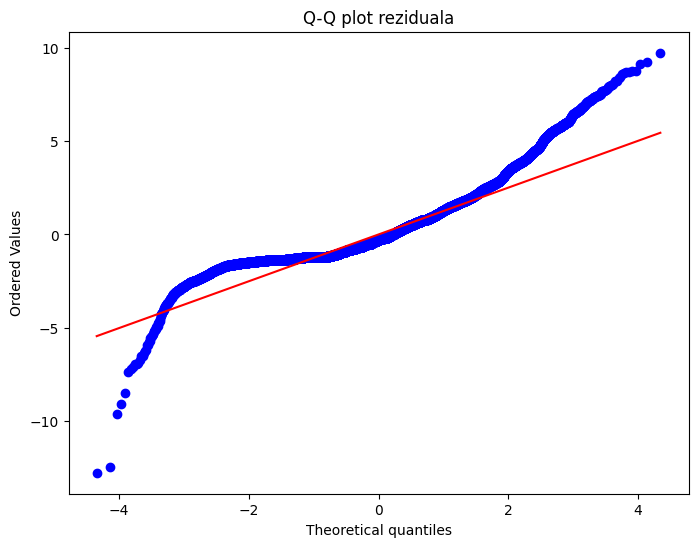

In [54]:
plt.figure(figsize=(8, 6))
stats_module.probplot(residual, dist="norm", plot=plt)
plt.title('Q-Q plot reziduala')
plt.show()

In [55]:
print(df[['sodium', 'bmi', 'respiration']].describe())
print(df[['sodium', 'bmi', 'respiration']].corr())

              sodium            bmi    respiration
count  100000.000000  100000.000000  100000.000000
mean      137.891397      29.805759       6.493768
std         2.999669       2.003769       0.568473
min       124.912632      21.992683       0.200000
25%       135.871062      28.454235       6.500000
50%       137.887151      29.807516       6.500000
75%       139.912885      31.156885       6.500000
max       151.387283      38.935293      10.000000
               sodium       bmi  respiration
sodium       1.000000  0.001101    -0.001444
bmi          0.001101  1.000000    -0.001450
respiration -0.001444 -0.001450     1.000000


In [56]:
X = df[predm]
y = df['lengthofstay']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Trening skup: {X_train.shape[0]}")
print(f"Test skup: {X_test.shape[0]}")

Trening skup: 80000
Test skup: 20000


In [57]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)

tp = mlr.predict(X_test)

print(f"R2: {r2_score(y_test, tp):.4f}")
print(f"MAE: {mean_absolute_error(y_test, tp):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, tp)):.4f}")

R2: 0.6902
MAE: 1.0250
RMSE: 1.3038


In [58]:
mrf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
mrf.fit(X_train, y_train)
prf = mrf.predict(X_test)

print(f"Random Forest R2: {r2_score(y_test, prf):.4f}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, prf):.4f}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_test, prf)):.4f}")

Random Forest R2: 0.8281
Random Forest MAE: 0.7597
Random Forest RMSE: 0.9712


In [59]:
imp = pd.DataFrame({'prediktor': predm, 'vaznost': mrf.feature_importances_ }).sort_values('vaznost', ascending=False)
print(imp)

                     prediktor   vaznost
0                       rcount  0.673607
12  psychologicaldisordermajor  0.104818
1                   hematocrit  0.064782
5               bloodureanitro  0.048294
9                  respiration  0.029195
7                          bmi  0.013260
3                       sodium  0.012975
6                   creatinine  0.012372
4                      glucose  0.011554
8                        pulse  0.010492
2                  neutrophils  0.008214
11                      asthma  0.007421
10       dialysisrenalendstage  0.003017


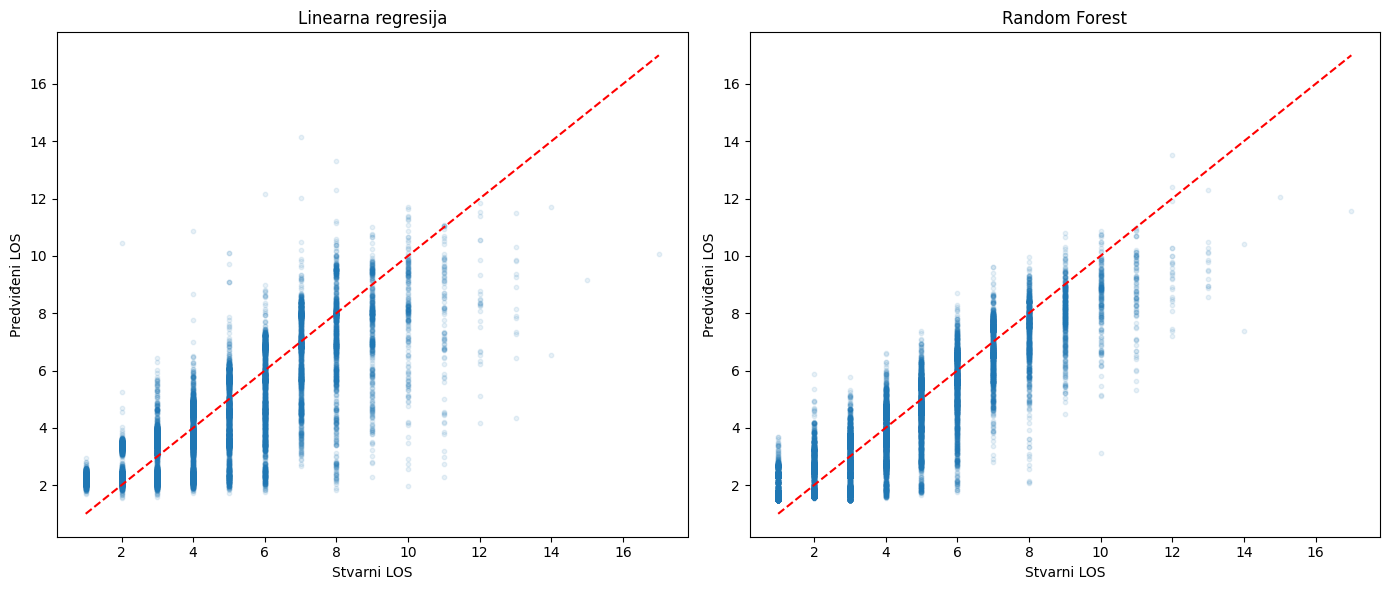

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(y_test, tp, alpha=0.1, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Stvarni LOS')
axes[0].set_ylabel('Predviđeni LOS')
axes[0].set_title('Linearna regresija')

axes[1].scatter(y_test, prf, alpha=0.1, s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Stvarni LOS')
axes[1].set_ylabel('Predviđeni LOS')
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()